<a href="https://colab.research.google.com/github/UzmaFatima07/MachineLearning_Internship/blob/main/Week2_UzmaFatima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Task 1: Load & Inspect the Ames Housing Dataset

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/UzmaFatima_ML_Internship_WEEK1_Submission/train.csv')

In [ ]:
print("Shape:", df.shape)
print("\nAll column names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (1460, 81)

All column names:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch'

In [ ]:
missing_count = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
})

top15 = missing_report[missing_report['Missing Count'] > 0].head(15)
print("Top 15 columns with missing values:")
print(top15)

Top 15 columns with missing values:
              Missing Count  Missing %
PoolQC                 1453      99.52
MiscFeature            1406      96.30
Alley                  1369      93.77
Fence                  1179      80.75
MasVnrType              872      59.73
FireplaceQu             690      47.26
LotFrontage             259      17.74
GarageQual               81       5.55
GarageFinish             81       5.55
GarageType               81       5.55
GarageYrBlt              81       5.55
GarageCond               81       5.55
BsmtFinType2             38       2.60
BsmtExposure             38       2.60
BsmtCond                 37       2.53


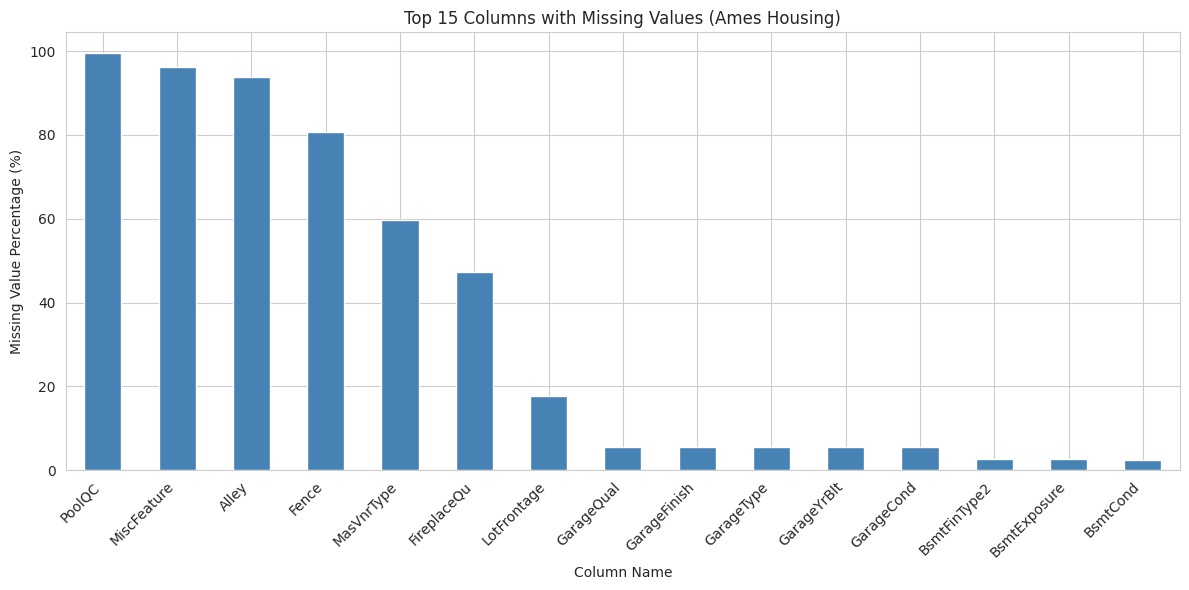

In [ ]:
plt.figure(figsize=(12, 6))
top15['Missing %'].plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 Columns with Missing Values (Ames Housing)')
plt.xlabel('Column Name')
plt.ylabel('Missing Value Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Task 2: Univariate Analysis(Titanic dataset)

In [ ]:
titanic = pd.read_csv('/content/drive/MyDrive/UzmaFatima_ML_Internship_WEEK1_Submission/train (titanic).csv')
print("Shape:", titanic.shape)
titanic.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


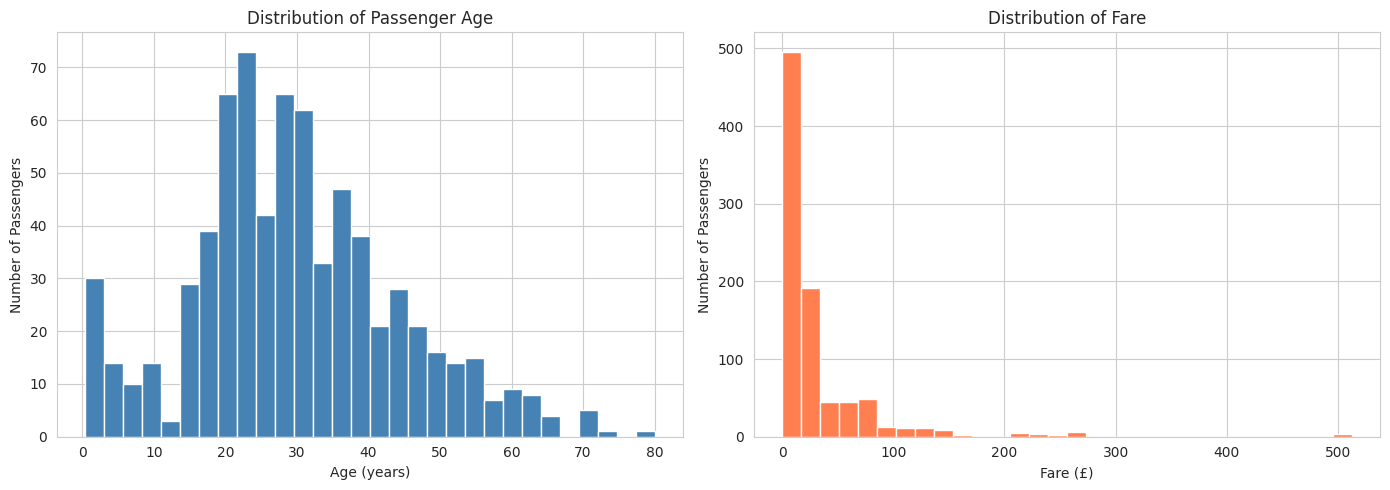

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(titanic['Age'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Passenger Age')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Number of Passengers')

axes[1].hist(titanic['Fare'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Fare')
axes[1].set_xlabel('Fare (£)')
axes[1].set_ylabel('Number of Passengers')

plt.tight_layout()
plt.show()

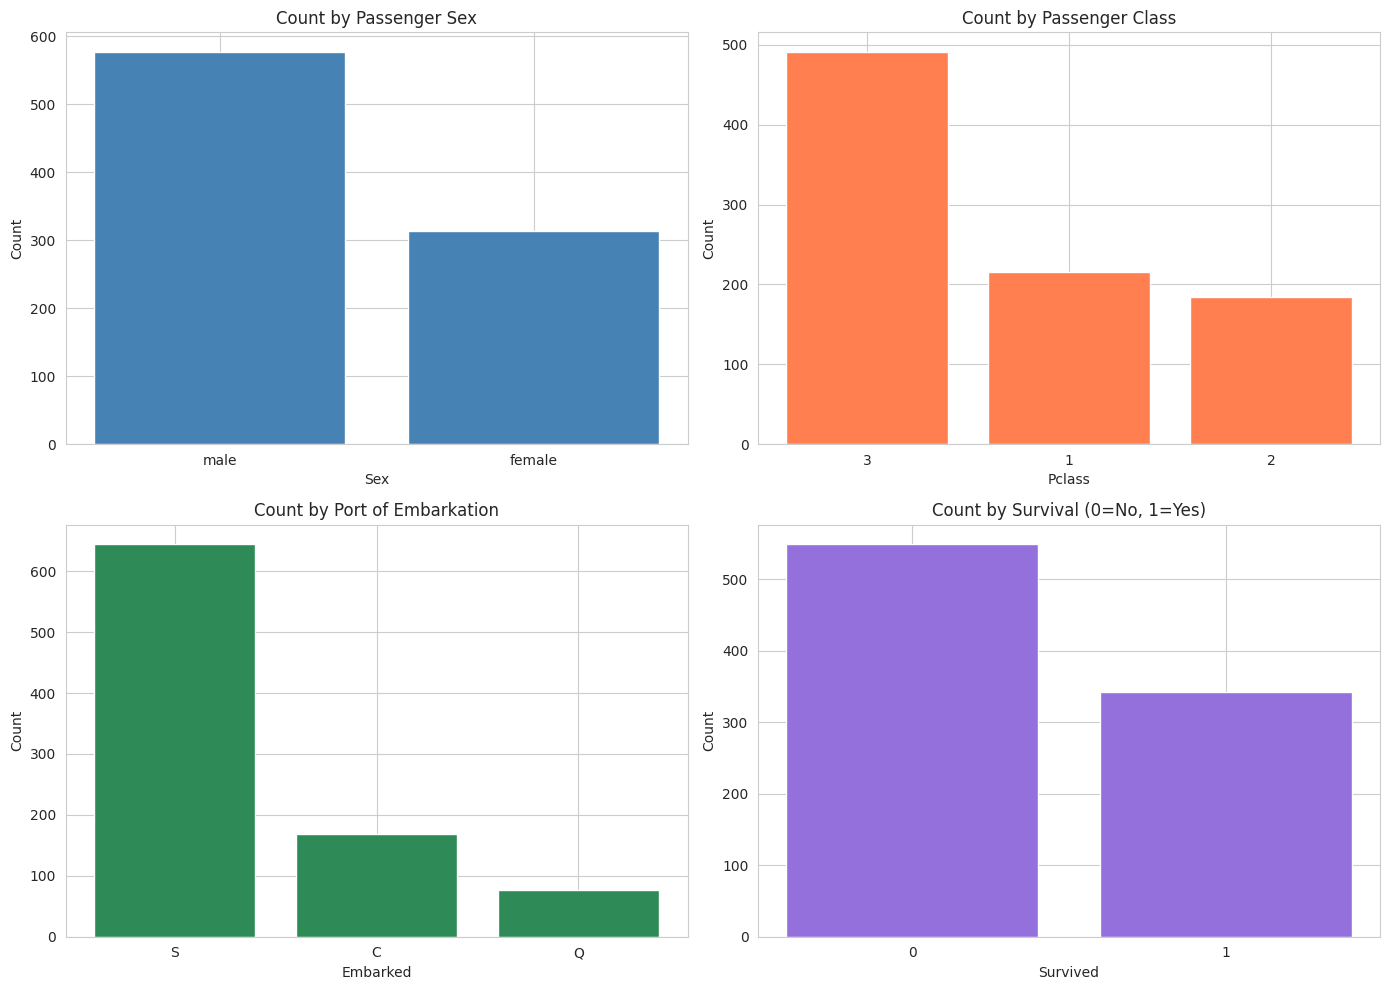

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cols = ['Sex', 'Pclass', 'Embarked', 'Survived']
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']
titles = ['Passenger Sex', 'Passenger Class', 'Port of Embarkation', 'Survival (0=No, 1=Yes)']

for i, (col, color, title) in enumerate(zip(cols, colors, titles)):
    ax = axes[i//2][i%2]
    counts = titanic[col].value_counts()
    ax.bar(counts.index.astype(str), counts.values, color=color, edgecolor='white')
    ax.set_title(f'Count by {title}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## Task 3: Bivariate Analysis

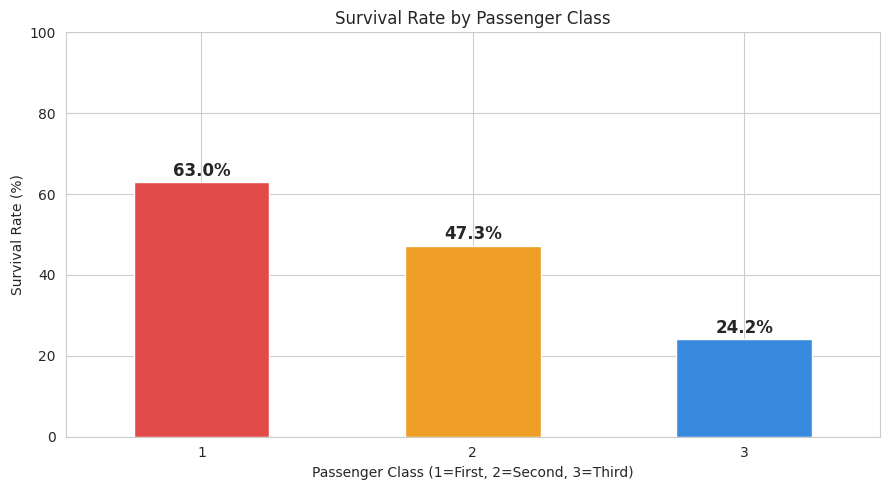

In [ ]:
plt.figure(figsize=(9, 5))

survival_by_class = titanic.groupby('Pclass')['Survived'].mean() * 100
survival_by_class.plot(kind='bar', color=['#E24B4A','#EF9F27','#378ADD'], edgecolor='white')

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
for i, v in enumerate(survival_by_class):
    plt.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

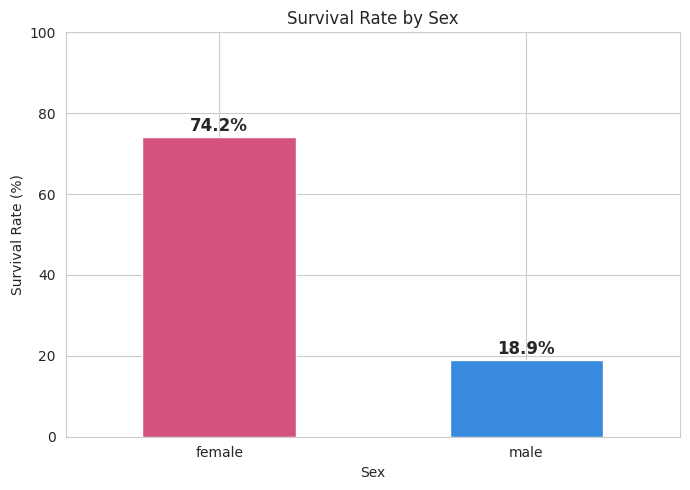

In [ ]:
plt.figure(figsize=(7, 5))

survival_by_sex = titanic.groupby('Sex')['Survived'].mean() * 100
survival_by_sex.plot(kind='bar', color=['#D4537E','#378ADD'], edgecolor='white')

plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
for i, v in enumerate(survival_by_sex):
    plt.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

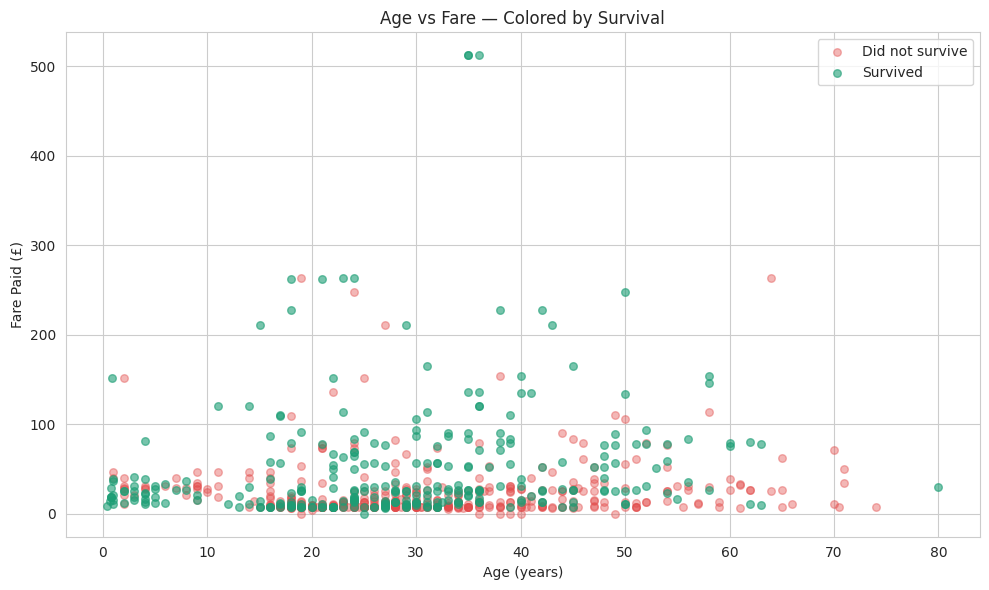

In [ ]:
plt.figure(figsize=(10, 6))

survived = titanic[titanic['Survived'] == 1]
not_survived = titanic[titanic['Survived'] == 0]

plt.scatter(not_survived['Age'], not_survived['Fare'],
            alpha=0.4, color='#E24B4A', label='Did not survive', s=30)
plt.scatter(survived['Age'], survived['Fare'],
            alpha=0.6, color='#1D9E75', label='Survived', s=30)

plt.title('Age vs Fare — Colored by Survival')
plt.xlabel('Age (years)')
plt.ylabel('Fare Paid (£)')
plt.legend()
plt.tight_layout()
plt.show()

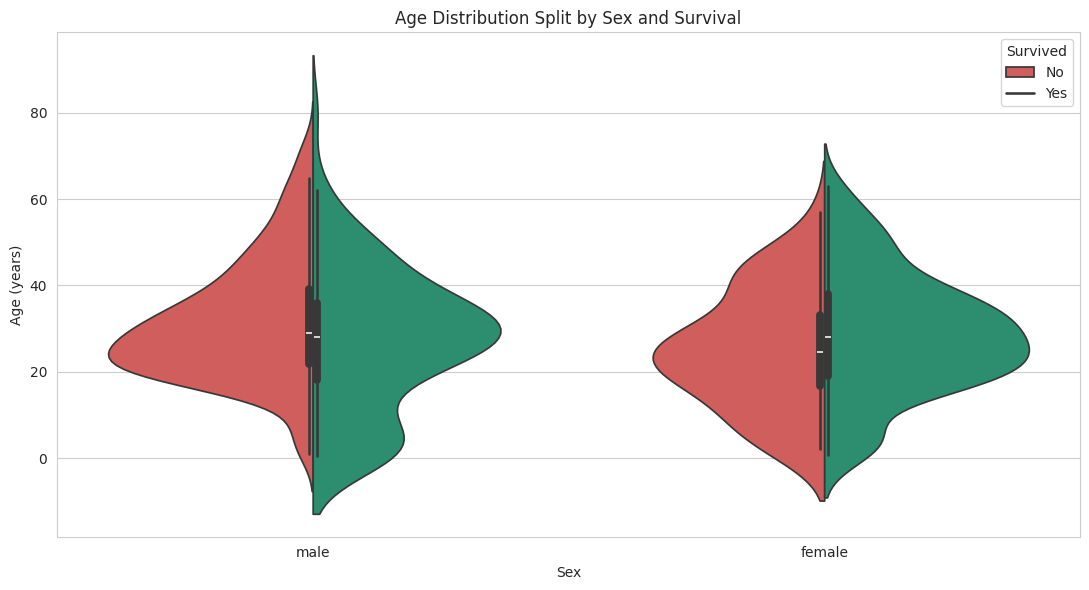

In [ ]:
plt.figure(figsize=(11, 6))

sns.violinplot(data=titanic, x='Sex', y='Age',
               hue='Survived', split=True, palette={0: '#E24B4A', 1: '#1D9E75'})

plt.title('Age Distribution Split by Sex and Survival')
plt.xlabel('Sex')
plt.ylabel('Age (years)')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

## Task 4: Correlation Analysis(Ames Housing)

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

print("Shape of correlation matrix:", corr_matrix.shape)
print("\nCorrelation with SalePrice (top 10):")
print(corr_matrix['SalePrice'].sort_values(ascending=False).head(10))

Shape of correlation matrix: (38, 38)

Correlation with SalePrice (top 10):
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


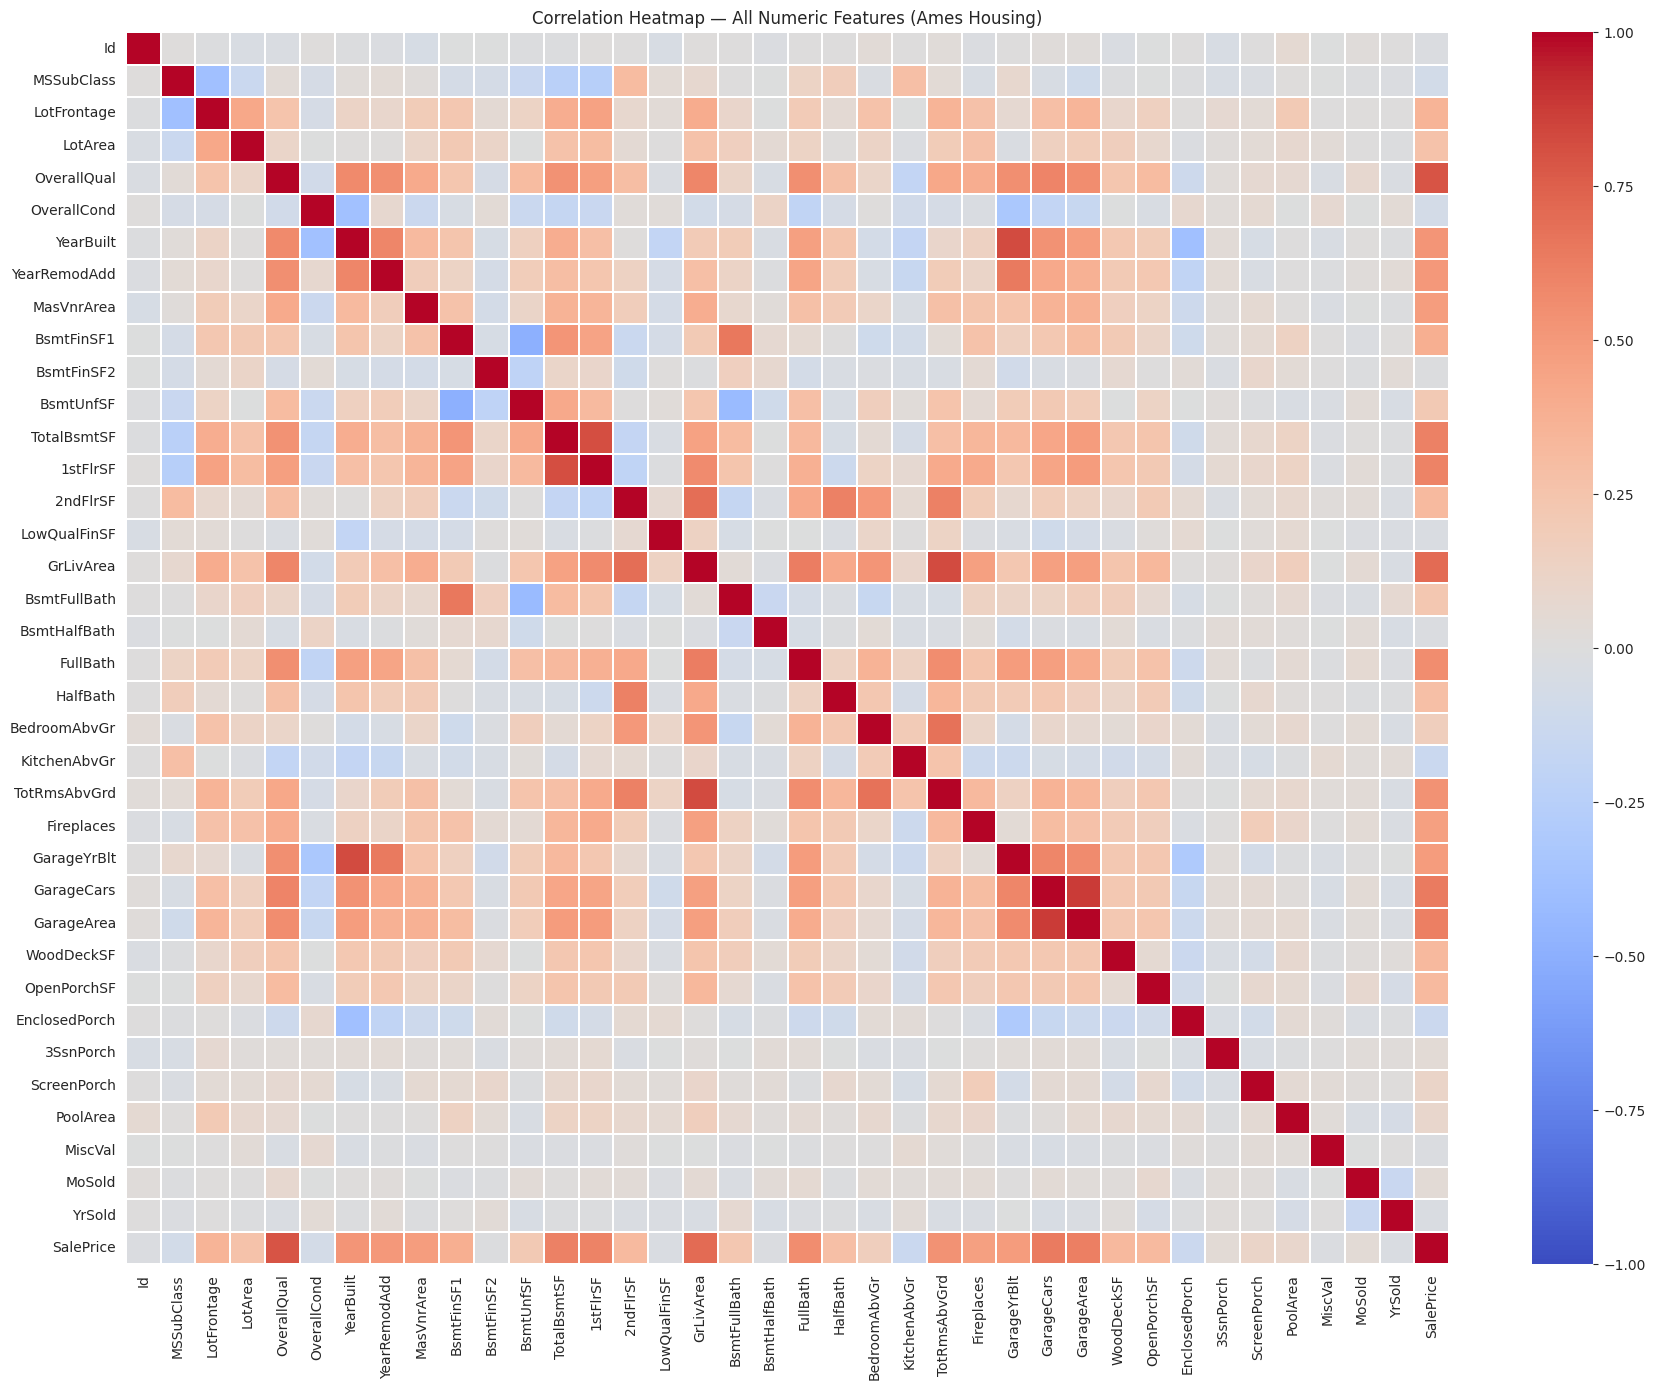

In [ ]:
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix,
            cmap='coolwarm',
            center=0,
            annot=False,
            linewidths=0.3,
            vmin=-1, vmax=1)
plt.title('Correlation Heatmap — All Numeric Features (Ames Housing)')
plt.tight_layout()
plt.show()

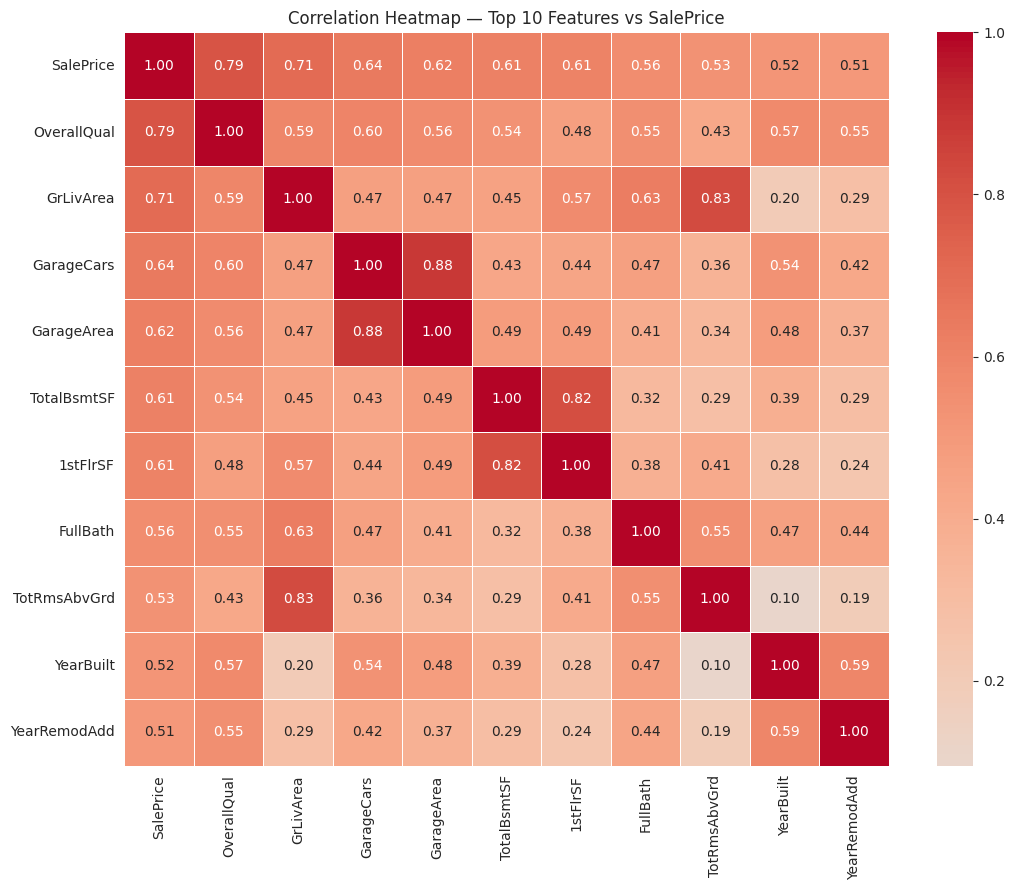

In [ ]:
top_feats = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(11).index
focused_corr = corr_matrix.loc[top_feats, top_feats]

plt.figure(figsize=(11, 9))
sns.heatmap(focused_corr,
            annot=True, fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 10})
plt.title('Correlation Heatmap — Top 10 Features vs SalePrice')
plt.tight_layout()
plt.show()

Identify the top 3 strongest correlated pairs

In [ ]:
import itertools

pairs = []
cols_list = corr_matrix.columns.tolist()
for c1, c2 in itertools.combinations(cols_list, 2):
    pairs.append((c1, c2, abs(corr_matrix.loc[c1, c2])))

pairs_df = pd.DataFrame(pairs, columns=['Feature 1', 'Feature 2', 'Abs Correlation'])
top3 = pairs_df.sort_values('Abs Correlation', ascending=False).head(3)
print("Top 3 most strongly correlated pairs:")
print(top3.to_string(index=False))

Top 3 most strongly correlated pairs:
 Feature 1    Feature 2  Abs Correlation
GarageCars   GarageArea         0.882475
 YearBuilt  GarageYrBlt         0.825667
 GrLivArea TotRmsAbvGrd         0.825489


## Task 5: EDA Summary — Key Findings

### Finding 1: Ames Housing has significant missing data in amenity features
The missing value bar chart (Task 1) revealed that PoolQC (99.5%),
MiscFeature (96.3%), Alley (93.8%), and Fence (80.8%) have the most
missing values. These are not data errors — they indicate the house
simply lacks that feature (e.g. no pool, no alley access). These columns
require special handling in preprocessing (Week 3).

### Finding 2: Fare is heavily right-skewed
The histogram in Task 2 shows most Titanic passengers paid fares below
£50, but a small number paid over £300. This skewness means we should
apply a log transformation before using Fare in any model.

### Finding 3: Sex is the strongest predictor of survival
The bar chart in Task 3 shows female passengers had a 74.2% survival rate
vs 18.9% for males. This is the single most impactful variable in the dataset.

### Finding 4: Passenger class strongly predicts survival
First-class passengers survived at 62.9%, second-class at 47.3%, and
third-class at only 24.2% (Task 3 bar chart). Class acted as a proxy
for access to lifeboats.

### Finding 5: OverallQual is the strongest predictor of SalePrice
The correlation heatmap (Task 4) shows OverallQual has the highest
correlation with SalePrice (r = 0.79), followed by GrLivArea (r = 0.71)
and GarageCars (r = 0.64). These should be prioritised as features.

### Finding 6: Multicollinearity exists between garage features
GarageCars and GarageArea have a correlation of ~0.88 (Task 4).
Including both in a model would be redundant — we should choose one.

---

### Features suggested for predicting survival (Titanic):
1. **Sex** — strongest single predictor (74% vs 19% survival rate)
2. **Pclass** — clear class-based survival gap (63% vs 24%)

### Features suggested for predicting SalePrice (Ames):
1. **OverallQual** — r = 0.79 with SalePrice
2. **GrLivArea** — r = 0.71, captures living area size